# Predicting Pavement Roughness (IRI) from Traffic and Climate Using Regression
**Author:** David Badu | **Data:** LTPP InfoPave (1989 to 2025)

**Aim:** predict the International Roughness Index (IRI, m/km) of LTPP pavement sections from traffic, climate and section history, and find which factors matter most.

## Step 1: Loading and inspecting the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("pavement_clean.csv", dtype={"SHRP_ID": str})

print(df)

       STATE_CODE SHRP_ID  CONSTRUCTION_NO  YEAR  N_RUNS  IRI_AVG  \
0               1    0502                1  1991       5   1.0360   
1               1    0502                2  1992       4   0.7745   
2               1    0502                2  1994       5   0.8540   
3               1    0502                2  1996       5   0.8193   
4               1    0502                2  1999       5   0.8143   
...           ...     ...              ...   ...     ...      ...   
15935          90    B351                2  1994       5   1.6446   
15936          90    B351                2  1995      10   1.9259   
15937          90    B351                3  1997       5   2.4953   
15938          90    B351                3  1998       5   2.5331   
15939          90    B351                3  1999       5   2.7157   

      STATE_CODE_EXP  ANNUAL_ESAL_TREND  AADTT_ALL_TRUCKS_TREND  \
0            Alabama            76486.0                   402.0   
1            Alabama            78986

In [2]:
df.info()             
df["IRI_AVG"].describe()
df["SECTION_ID"].nunique()

<class 'pandas.DataFrame'>
RangeIndex: 15940 entries, 0 to 15939
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   STATE_CODE                15940 non-null  int64  
 1   SHRP_ID                   15940 non-null  str    
 2   CONSTRUCTION_NO           15940 non-null  int64  
 3   YEAR                      15940 non-null  int64  
 4   N_RUNS                    15940 non-null  int64  
 5   IRI_AVG                   15940 non-null  float64
 6   STATE_CODE_EXP            15940 non-null  str    
 7   ANNUAL_ESAL_TREND         15940 non-null  float64
 8   AADTT_ALL_TRUCKS_TREND    15940 non-null  float64
 9   AADTT_VEH_CLASS_4_TREND   15940 non-null  float64
 10  AADTT_VEH_CLASS_5_TREND   15940 non-null  float64
 11  AADTT_VEH_CLASS_6_TREND   15940 non-null  float64
 12  AADTT_VEH_CLASS_7_TREND   15940 non-null  float64
 13  AADTT_VEH_CLASS_8_TREND   15940 non-null  float64
 14  AADTT_VEH_CLASS_9

1550

In [3]:
print(df.describe())

         STATE_CODE  CONSTRUCTION_NO          YEAR        N_RUNS  \
count  15940.000000     15940.000000  15940.000000  15940.000000   
mean      33.436763         2.390402   1998.925282      5.430552   
std       22.849748         1.588858      7.137056      2.220288   
min        1.000000         1.000000   1989.000000      1.000000   
25%       17.000000         1.000000   1993.000000      5.000000   
50%       30.000000         2.000000   1998.000000      5.000000   
75%       48.000000         3.000000   2003.000000      5.000000   
max       90.000000        15.000000   2025.000000     45.000000   

            IRI_AVG  ANNUAL_ESAL_TREND  AADTT_ALL_TRUCKS_TREND  \
count  15940.000000       1.594000e+04            15940.000000   
mean       1.346284       3.400738e+05              920.566562   
std        0.615442       4.888482e+05             1066.995860   
min        0.319400       0.000000e+00                1.000000   
25%        0.929175       5.346000e+04              260.0

In [4]:
df.groupby("SECTION_ID").size().describe()
df[df["SECTION_ID"] == "01_0502"][["YEAR", "CONSTRUCTION_NO", "IRI_AVG"]]

,YEAR,CONSTRUCTION_NO,IRI_AVG
0,1991,1,1.0360
1,1992,2,0.7745
2,1994,2,0.8540
3,1996,2,0.8193
4,1999,2,0.8143
5,2001,2,0.8377
6,2002,2,0.8422
7,2003,2,0.8877
8,2004,2,0.9545
9,2005,2,1.0105


**Note:** 15,940 rows but only 1,550 sections: each section was surveyed about 10 times (panel data). Surveys of the same road are not independent, so train/test splits must keep each road on one side.

## Step 2: Understanding the target (IRI)

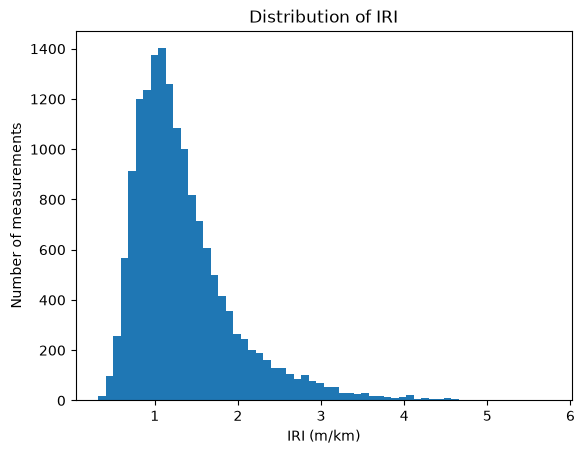

In [5]:
plt.hist(df["IRI_AVG"], bins=60)
plt.xlabel("IRI (m/km)")
plt.ylabel("Number of measurements")
plt.title("Distribution of IRI")
plt.show()

In [6]:
print(df["IRI_AVG"].skew())


1.7100164230236399


In [7]:
df["LOG_IRI"] = np.log(df["IRI_AVG"])
print(df["LOG_IRI"].skew())

0.35096673599308564


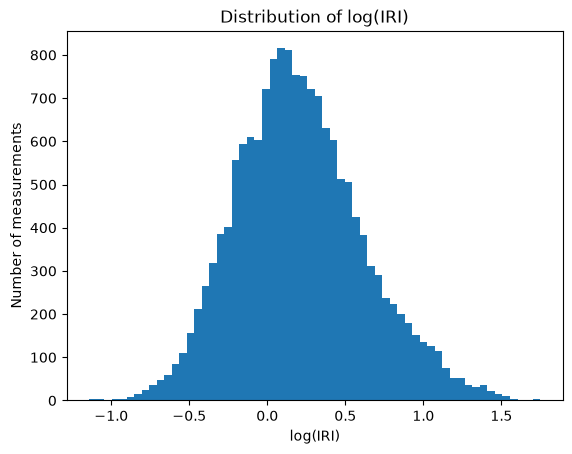

In [8]:
plt.hist(df["LOG_IRI"], bins=60)
plt.xlabel("log(IRI)")
plt.ylabel("Number of measurements")
plt.title("Distribution of log(IRI)")
plt.show()

IRI is right-skewed (1.71). The log transform reduces this to 0.35, so log(IRI) will be tested as the target.

### Pavement condition classes (FHWA: Good < 1.50, Fair 1.50 to 2.68, Poor > 2.68 m/km)

In [9]:
df["CONDITION"] = pd.cut(df["IRI_AVG"],
                         bins=[0, 1.50, 2.68, np.inf],
                         labels=["Good", "Fair", "Poor"])
df["CONDITION"].value_counts()

CONDITION
Good    11279
Fair     3966
Poor      695
Name: count, dtype: int64

In [10]:
df["CONDITION"].value_counts(normalize=True)

CONDITION
Good    0.707591
Fair    0.248808
Poor    0.043601
Name: proportion, dtype: float64

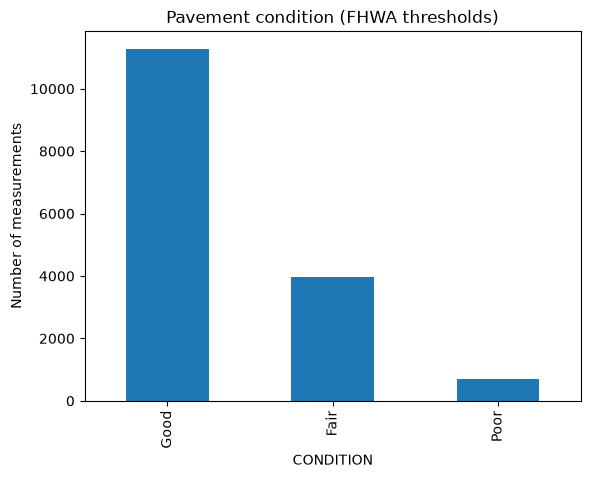

In [11]:
df["CONDITION"].value_counts().plot(kind="bar")
plt.ylabel("Number of measurements")
plt.title("Pavement condition (FHWA thresholds)")
plt.show()

**Note:** 70.8% Good, 24.9% Fair, 4.4% Poor. The classes are imbalanced: a model that always says "Good" is 70.8% accurate but finds no poor roads, so accuracy alone is misleading.

## Step 3: Exploring the predictors
### 3a. IRI and pavement age

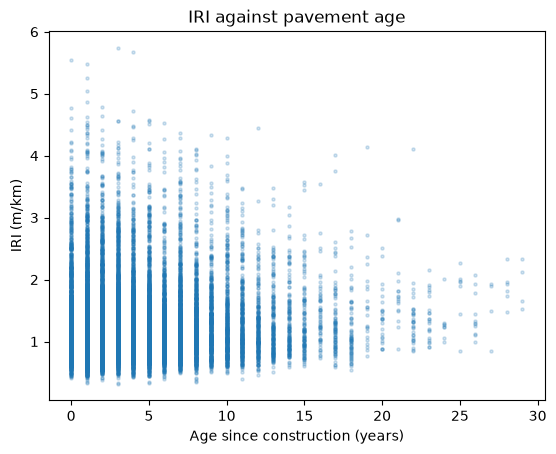

In [12]:
plt.scatter(df["AGE_SINCE_CN"], df["IRI_AVG"], s=5, alpha=0.2)
plt.xlabel("Age since construction (years)")
plt.ylabel("IRI (m/km)")
plt.title("IRI against pavement age")
plt.show()

In [13]:
median_by_age = df.groupby("AGE_SINCE_CN")["IRI_AVG"].median()
median_by_age

AGE_SINCE_CN
0     1.199800
1     1.184400
2     1.171900
3     1.209400
4     1.182200
5     1.222400
6     1.180050
7     1.247000
8     1.213250
9     1.231500
10    1.178150
11    1.190625
12    1.129500
13    1.162500
14    1.173400
15    1.175400
16    1.350400
17    1.202400
18    1.046700
19    1.474850
20    1.360500
21    1.702032
22    1.319300
23    1.344150
24    1.250350
25    1.955000
26    1.300500
27    1.696150
28    1.865850
29    1.883850
Name: IRI_AVG, dtype: float64

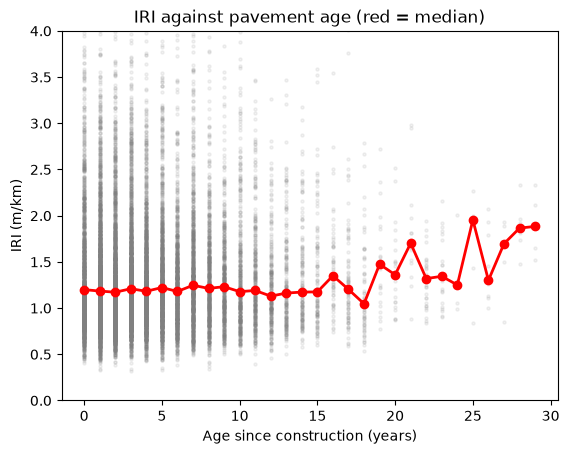

In [14]:
plt.scatter(df["AGE_SINCE_CN"], df["IRI_AVG"], s=5, alpha=0.1, color="grey")
plt.plot(median_by_age.index, median_by_age.values, color="red", marker="o", linewidth=2)
plt.xlabel("Age since construction (years)")
plt.ylabel("IRI (m/km)")
plt.title("IRI against pavement age (red = median)")
plt.ylim(0, 4)
plt.show()

In [15]:
df["AGE_SINCE_CN"].value_counts().sort_index()

AGE_SINCE_CN
0     1552
1     2347
2     2058
3     2087
4     1607
5     1319
6      966
7      940
8      704
9      507
10     438
11     343
12     256
13     193
14     145
15     116
16      56
17      84
18      67
19      22
20      24
21      16
22      31
23      22
24       8
25       7
26      11
27       4
28       6
29       4
Name: count, dtype: int64

In [16]:
(df["AGE_SINCE_CN"] > 20).sum()

np.int64(109)

In [17]:
df = df.sort_values(["SECTION_ID", "CONSTRUCTION_NO", "YEAR"])
first_iri = df.groupby(["SECTION_ID", "CONSTRUCTION_NO"])["IRI_AVG"].transform("first")
df["IRI_CHANGE"] = df["IRI_AVG"] - first_iri

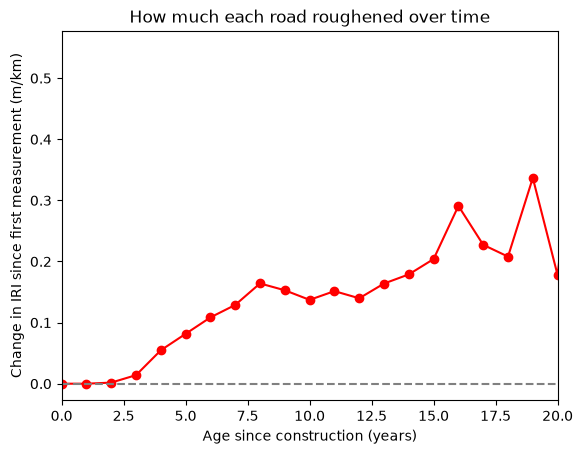

In [18]:
change_by_age = df.groupby("AGE_SINCE_CN")["IRI_CHANGE"].median()
plt.plot(change_by_age.index, change_by_age.values, marker="o", color="red")
plt.axhline(0, color="grey", linestyle="--")
plt.xlabel("Age since construction (years)")
plt.ylabel("Change in IRI since first measurement (m/km)")
plt.title("How much each road roughened over time")
plt.xlim(0, 20)
plt.show()

**Note:** median IRI is almost flat with age across all roads (1.13 to 1.25 m/km for ages 0 to 15), but each road's own IRI rises by about 0.2 m/km over 15 years. Rehabilitation resets age (survivorship bias) and roads start at different roughness, which hides the trend.

### 3b. IRI by pavement type
Rigid pavements are rougher: median 1.84 vs 1.17 m/km for flexible.

In [19]:
df.groupby("PAVEMENT_TYPE")["IRI_AVG"].median()

PAVEMENT_TYPE
Flexible    1.173000
Rigid       1.842475
Name: IRI_AVG, dtype: float64

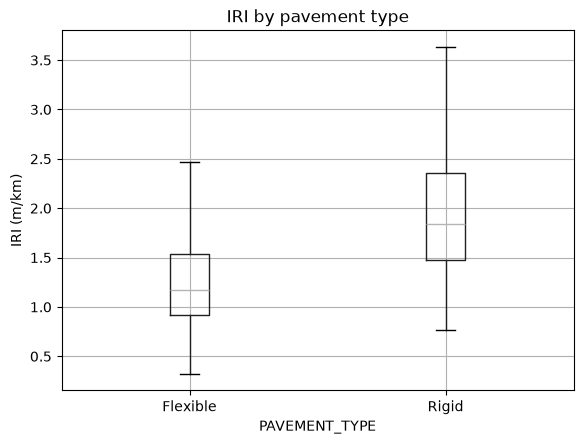

In [20]:
df.boxplot(column="IRI_AVG", by="PAVEMENT_TYPE", showfliers=False)
plt.ylabel("IRI (m/km)")
plt.title("IRI by pavement type")
plt.suptitle("")
plt.show()

### 3c. IRI and traffic
No clear upward trend. Busier roads are built thicker and maintained more (confounding).

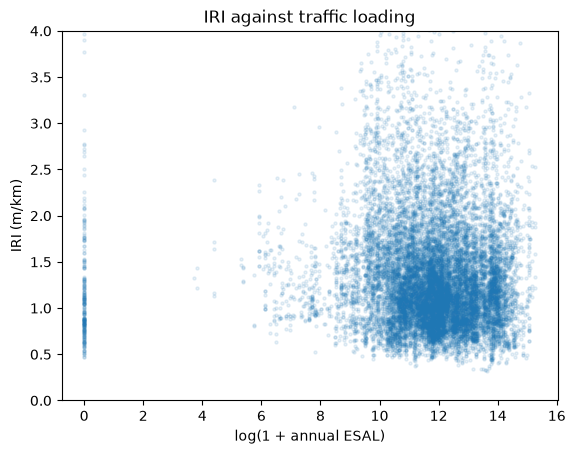

In [21]:
plt.scatter(df["LOG_ESAL"], df["IRI_AVG"], s=5, alpha=0.1)
plt.xlabel("log(1 + annual ESAL)")
plt.ylabel("IRI (m/km)")
plt.title("IRI against traffic loading")
plt.ylim(0, 4)
plt.show()

### 3d. IRI and climate

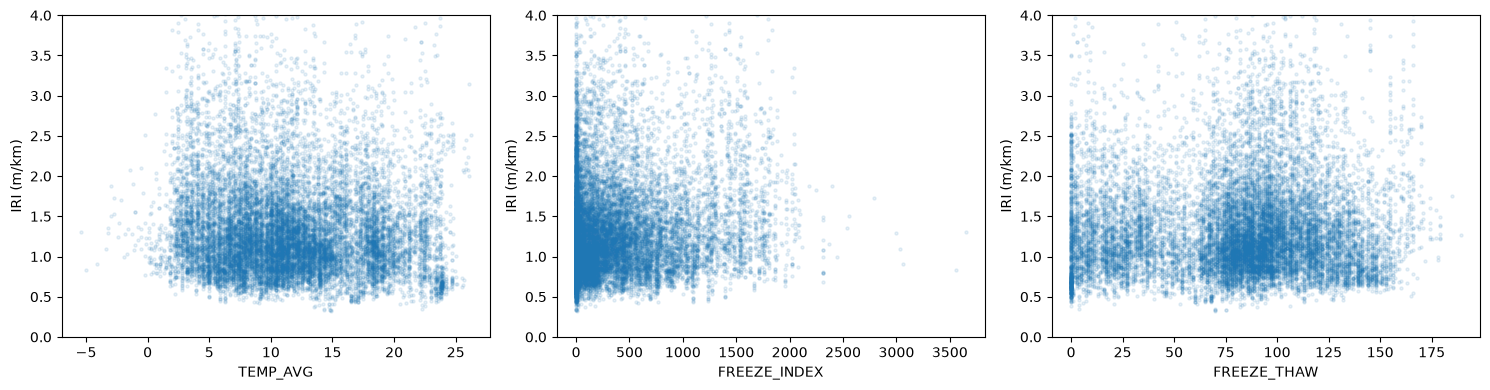

In [22]:
climate = ["TEMP_AVG", "FREEZE_INDEX", "FREEZE_THAW"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(climate):
    axes[i].scatter(df[col], df["IRI_AVG"], s=5, alpha=0.1)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("IRI (m/km)")
    axes[i].set_ylim(0, 4)

plt.tight_layout()
plt.show()

### 3e. Correlation

In [23]:
features = ["AGE_SINCE_CN", "IS_REHAB", "LOG_ESAL", "LOG_AADTT", "SHARE_CLASS9",
            "TEMP_AVG", "FREEZE_INDEX", "FREEZE_THAW", "URBAN"]

corr_with_iri = df[features + ["IRI_AVG"]].corr()["IRI_AVG"].drop("IRI_AVG")
corr_with_iri.sort_values()

LOG_AADTT      -0.108473
TEMP_AVG       -0.091429
IS_REHAB       -0.085153
SHARE_CLASS9   -0.058005
LOG_ESAL       -0.027503
AGE_SINCE_CN   -0.001216
URBAN           0.035866
FREEZE_THAW     0.038113
FREEZE_INDEX    0.121047
Name: IRI_AVG, dtype: float64

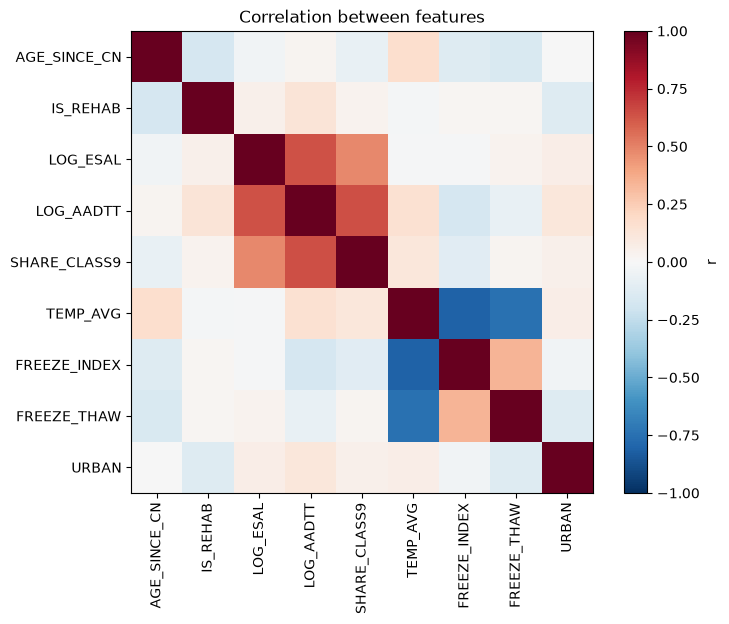

In [24]:
corr_matrix = df[features].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(label="r")
plt.xticks(range(len(features)), features, rotation=90)
plt.yticks(range(len(features)), features)
plt.title("Correlation between features")
plt.show()

**Summary of Step 3:** every feature has a weak correlation with IRI (below 0.13 in size). Temperature and freezing index overlap strongly (multicollinearity). Expect a modest R² from these features.

## Step 4: Preparing the features
Remove 5 impossible rows (Class 9 share above 100%), create IS_RIGID, then build X (15,935 × 10) and y.

In [25]:
print("Rows before:", len(df))
df = df[df["SHARE_CLASS9"] <= 1].copy()
print("Rows after: ", len(df))

Rows before: 15940
Rows after:  15935


In [26]:
df["IS_RIGID"] = (df["PAVEMENT_TYPE"] == "Rigid").astype(int)
df["IS_RIGID"].value_counts()

IS_RIGID
0    15113
1      822
Name: count, dtype: int64

In [27]:
features = ["AGE_SINCE_CN", "IS_REHAB", "IS_RIGID", "URBAN",
            "LOG_ESAL", "LOG_AADTT", "SHARE_CLASS9",
            "TEMP_AVG", "FREEZE_INDEX", "FREEZE_THAW"]
target = "IRI_AVG"

In [28]:
X = df[features].to_numpy()
y = df[target].to_numpy()
groups = df["SECTION_ID"].to_numpy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("First row of X:", X[0])
print("First y:", y[0])

X shape: (15935, 10)
y shape: (15935,)
First row of X: [ 4.          0.          0.          0.         11.24487607  5.99893656
  0.37064677 18.70000076  0.         20.        ]
First y: 1.0360000014305115


In [29]:
df[features].describe().loc[["min", "max", "mean", "std"]].T

,min,max,mean,std
AGE_SINCE_CN,0.000000,29.000000,4.569187,4.120681
IS_REHAB,0.000000,1.000000,0.703922,0.456540
IS_RIGID,0.000000,1.000000,0.051585,0.221194
URBAN,0.000000,1.000000,0.073423,0.260838
LOG_ESAL,0.000000,15.264397,11.692528,2.065318
LOG_AADTT,0.693147,9.627141,6.237250,1.190358
SHARE_CLASS9,0.000000,0.888889,0.470877,0.214888
TEMP_AVG,-5.400000,26.200001,11.481851,5.491661
FREEZE_INDEX,0.000000,3647.000000,383.749106,461.104034
FREEZE_THAW,0.000000,189.000000,79.926075,40.582693


### Feature scaling
Features have very different ranges (FREEZE_INDEX up to 3,647, SHARE_CLASS9 below 1), so they are scaled to mean 0 and standard deviation 1. μ and σ are computed from the training set only, after the split.

In [30]:
def zscore_normalize(X, mu, sigma):
    """Scale each column of X to mean 0 and standard deviation 1."""
    return (X - mu) / sigma

## Step 5: Splitting into training and test sets
80% of roads for training, 20% for testing, split by SECTION_ID so no road appears in both sets.

In [31]:
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print("Training rows:", len(train_idx))
print("Test rows:    ", len(test_idx))

Training rows: 12855
Test rows:     3080


In [32]:
train_roads = set(groups[train_idx])
test_roads = set(groups[test_idx])

print("Roads in training:", len(train_roads))
print("Roads in test:    ", len(test_roads))
print("Roads in both:    ", len(train_roads & test_roads))

Roads in training: 1240
Roads in test:     310
Roads in both:     0


In [33]:
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0)

X_train_norm = zscore_normalize(X_train, mu, sigma)
X_test_norm = zscore_normalize(X_test, mu, sigma)

In [34]:
print("Training means:", X_train_norm.mean(axis=0).round(2))
print("Training stds: ", X_train_norm.std(axis=0).round(2))
print("Test means:    ", X_test_norm.mean(axis=0).round(2))

Training means: [-0.  0.  0. -0. -0. -0. -0.  0. -0.  0.]
Training stds:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Test means:     [-0.02 -0.05 -0.01  0.   -0.09 -0.08 -0.06  0.    0.01 -0.01]


In [35]:
print("Before scaling, first training row:", X_train[0].round(2))
print("After scaling,  first training row:", X_train_norm[0].round(2))

Before scaling, first training row: [ 4.    0.    0.    0.   11.24  6.    0.37 18.7   0.   20.  ]
After scaling,  first training row: [-0.14 -1.56 -0.23 -0.28 -0.24 -0.22 -0.48  1.32 -0.82 -1.48]


## Step 6: Linear regression from scratch
Model f = w·x + b; cost J = average squared error / 2; gradient descent updates w and b step by step.

In [36]:
def predict(X, w, b):
    """Predict IRI for every row of X."""
    return X @ w + b

In [37]:
def compute_cost(X, y, w, b):
    """Mean squared error cost J(w,b), as in the course."""
    m = X.shape[0]
    errors = predict(X, w, b) - y
    cost = np.sum(errors ** 2) / (2 * m)
    return cost

In [38]:
w_zero = np.zeros(X_train_norm.shape[1])
print("Cost with all-zero weights:", compute_cost(X_train_norm, y_train, w_zero, 0))

Cost with all-zero weights: 1.0809447194260595


In [39]:
def compute_gradient(X, y, w, b):
    """Partial derivatives of J with respect to w and b."""
    m = X.shape[0]
    errors = predict(X, w, b) - y
    dj_dw = (X.T @ errors) / m
    dj_db = np.sum(errors) / m
    return dj_dw, dj_db

In [40]:
def gradient_descent(X, y, w_init, b_init, alpha, num_iters):
    """Run gradient descent and record the cost at every step."""
    w = w_init.copy()
    b = b_init
    J_history = []

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(X, y, w, b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        J_history.append(compute_cost(X, y, w, b))

        if i % 100 == 0:
            print(f"Iteration {i:4d}: cost = {J_history[-1]:.5f}")

    return w, b, J_history

In [41]:
w_init = np.zeros(X_train_norm.shape[1])
b_init = 0.0
alpha = 0.1
iterations = 1000

w_final, b_final, J_hist = gradient_descent(X_train_norm, y_train, w_init, b_init,
                                            alpha, iterations)

print(f"\nFinal b: {b_final:.4f}")
print(f"Final cost: {J_hist[-1]:.5f}")

Iteration    0: cost = 0.90756
Iteration  100: cost = 0.17009
Iteration  200: cost = 0.17007
Iteration  300: cost = 0.17007
Iteration  400: cost = 0.17007
Iteration  500: cost = 0.17007
Iteration  600: cost = 0.17007
Iteration  700: cost = 0.17007
Iteration  800: cost = 0.17007
Iteration  900: cost = 0.17007

Final b: 1.3356
Final cost: 0.17007


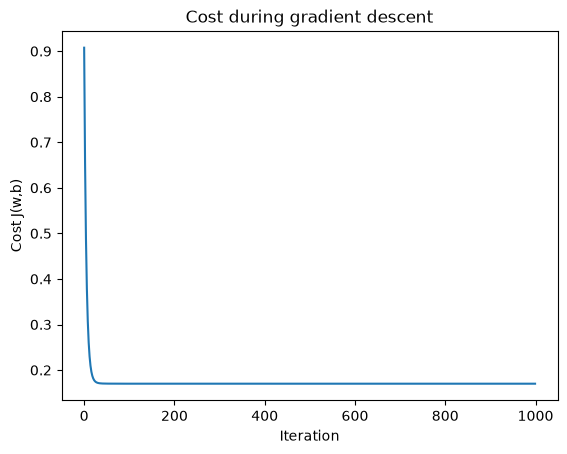

In [42]:
plt.plot(J_hist)
plt.xlabel("Iteration")
plt.ylabel("Cost J(w,b)")
plt.title("Cost during gradient descent")
plt.show()

### Learning rate experiment
α = 0.001 is too slow; 0.01 to 0.5 converge; 1.0 diverges (cost becomes inf).

In [43]:
for a in [0.001, 0.01, 0.1, 0.5, 1.0]:
    w_try, b_try, J_try = gradient_descent(X_train_norm, y_train, w_init, 0.0, a, 1000)
    print(f"alpha = {a}: final cost = {J_try[-1]}")

Iteration    0: cost = 1.07912
Iteration  100: cost = 0.91402
Iteration  200: cost = 0.77906
Iteration  300: cost = 0.66870
Iteration  400: cost = 0.57842
Iteration  500: cost = 0.50456
Iteration  600: cost = 0.44411
Iteration  700: cost = 0.39464
Iteration  800: cost = 0.35413
Iteration  900: cost = 0.32097
alpha = 0.001: final cost = 0.2940654903733013
Iteration    0: cost = 1.06278
Iteration  100: cost = 0.29054
Iteration  200: cost = 0.18693
Iteration  300: cost = 0.17274
Iteration  400: cost = 0.17066
Iteration  500: cost = 0.17029
Iteration  600: cost = 0.17018
Iteration  700: cost = 0.17013
Iteration  800: cost = 0.17011
Iteration  900: cost = 0.17010
alpha = 0.01: final cost = 0.1700874090169763
Iteration    0: cost = 0.90756
Iteration  100: cost = 0.17009
Iteration  200: cost = 0.17007
Iteration  300: cost = 0.17007
Iteration  400: cost = 0.17007
Iteration  500: cost = 0.17007
Iteration  600: cost = 0.17007
Iteration  700: cost = 0.17007
Iteration  800: cost = 0.17007
Iteratio

c:\Users\badud\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\badud\AppData\Local\Temp\ipykernel_18668\2523154185.py:5: RuntimeWarning: overflow encountered in square
  cost = np.sum(errors ** 2) / (2 * m)


In [44]:
weights = pd.Series(w_final, index=features).sort_values()
weights

LOG_AADTT      -0.128142
IS_REHAB       -0.013142
TEMP_AVG       -0.010310
FREEZE_THAW    -0.009423
AGE_SINCE_CN    0.009353
SHARE_CLASS9    0.018014
URBAN           0.019237
LOG_ESAL        0.047233
FREEZE_INDEX    0.067706
IS_RIGID        0.157116
dtype: float64

In [45]:
from sklearn.linear_model import LinearRegression

sk_model = LinearRegression()
sk_model.fit(X_train_norm, y_train)

print("Your w:   ", w_final.round(4))
print("sklearn w:", sk_model.coef_.round(4))
print("Your b:   ", round(b_final, 4))
print("sklearn b:", round(sk_model.intercept_, 4))

Your w:    [ 0.0094 -0.0131  0.1571  0.0192  0.0472 -0.1281  0.018  -0.0103  0.0677
 -0.0094]
sklearn w: [ 0.0094 -0.0131  0.1571  0.0192  0.0472 -0.1281  0.018  -0.0103  0.0677
 -0.0094]
Your b:    1.3356
sklearn b: 1.3356


**Note:** my gradient descent weights match scikit-learn to 4 decimal places, so the code is correct. b = 1.3356 equals the average training IRI.

## Step 7: Evaluating the model

In [46]:
y_train_pred = predict(X_train_norm, w_final, b_final)
y_test_pred = predict(X_test_norm, w_final, b_final)

In [47]:
def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot

print("Train R²:", round(r_squared(y_train, y_train_pred), 3))
print("Test R²: ", round(r_squared(y_test, y_test_pred), 3))

Train R²: 0.1
Test R²:  0.068


In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def report(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name:10s}  R² = {r2:6.3f}   RMSE = {rmse:.3f}   MAE = {mae:.3f}")

report("Train", y_train, y_train_pred)
report("Test", y_test, y_test_pred)

Train       R² =  0.100   RMSE = 0.583   MAE = 0.420
Test        R² =  0.068   RMSE = 0.595   MAE = 0.433


In [49]:
y_baseline = np.full(len(y_test), y_train.mean())
report("Baseline", y_test, y_baseline)

Baseline    R² = -0.008   RMSE = 0.619   MAE = 0.450


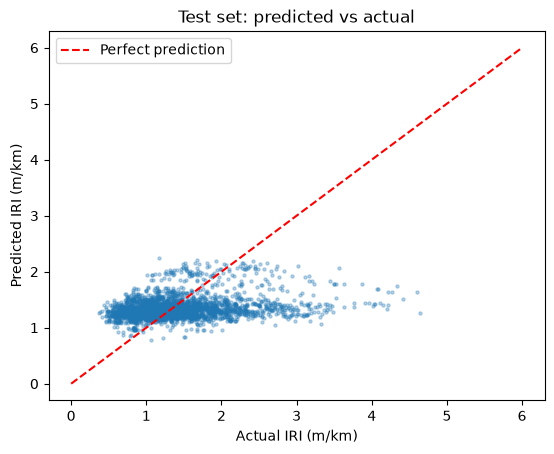

In [50]:
plt.scatter(y_test, y_test_pred, s=5, alpha=0.3)
plt.plot([0, 6], [0, 6], color="red", linestyle="--", label="Perfect prediction")
plt.xlabel("Actual IRI (m/km)")
plt.ylabel("Predicted IRI (m/km)")
plt.title("Test set: predicted vs actual")
plt.legend()
plt.show()

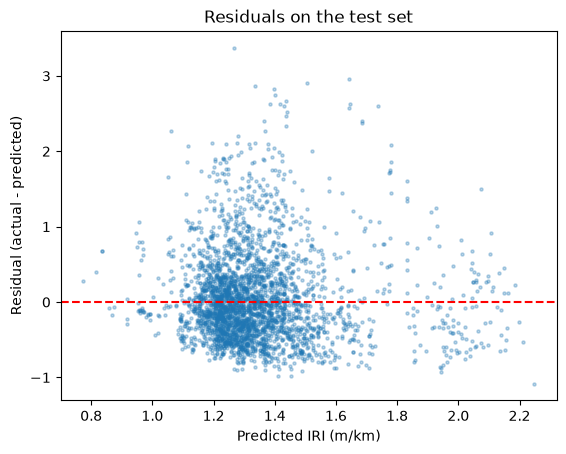

In [51]:
residuals = y_test - y_test_pred

plt.scatter(y_test_pred, residuals, s=5, alpha=0.3)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted IRI (m/km)")
plt.ylabel("Residual (actual - predicted)")
plt.title("Residuals on the test set")
plt.show()

In [52]:
log_model = LinearRegression()
log_model.fit(X_train_norm, np.log(y_train))

y_test_pred_log = np.exp(log_model.predict(X_test_norm))
report("Log model", y_test, y_test_pred_log)

Log model   R² =  0.004   RMSE = 0.615   MAE = 0.431


**Result:** train R² 0.100, test R² 0.068, test RMSE 0.595 vs 0.619 for the baseline (about 4% better). Train and test are both low and close: **underfitting (high bias)**. The log target gave R² 0.004, so plain IRI is kept.

## Step 8: Polynomial features and regularisation

In [53]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline

model = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(),
    LinearRegression()
)
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler-1', ...), ('polynomialfeatures', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value
"mean_ mean_: ndarray of shape (n_features,) or NoneThe mean value for each feature in the training set.Equal to ``None`` when ``with_mean=False`` and ``with_std=False``.","ndarray[float64](10,)","[ 4.59, 0.71, 0.05,..., 11.48,383.16, 80.01]"


In [54]:
for degree in [1, 2, 3, 4]:
    model = make_pipeline(
        StandardScaler(),
        PolynomialFeatures(degree=degree, include_bias=False),
        StandardScaler(),
        LinearRegression()
    )
    model.fit(X_train, y_train)
    train_r2 = r2_score(y_train, model.predict(X_train))
    test_r2 = r2_score(y_test, model.predict(X_test))
    print(f"Degree {degree}:  train R² = {train_r2:.3f}   test R² = {test_r2:.3f}")

Degree 1:  train R² = 0.100   test R² = 0.068
Degree 2:  train R² = 0.155   test R² = 0.073
Degree 3:  train R² = 0.244   test R² = 0.020
Degree 4:  train R² = 0.364   test R² = -1.870


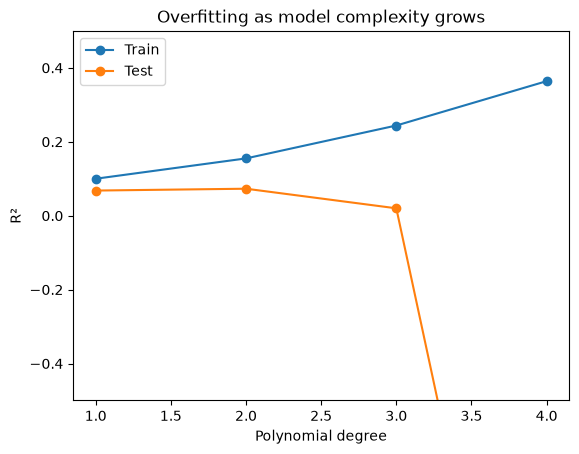

In [55]:
degrees = [1, 2, 3, 4]
train_scores = [0.100, 0.155, 0.244, 0.364]   # replace with your own results
test_scores = [0.068, 0.073, 0.020, -1.87]

plt.plot(degrees, train_scores, marker="o", label="Train")
plt.plot(degrees, test_scores, marker="o", label="Test")
plt.xlabel("Polynomial degree")
plt.ylabel("R²")
plt.ylim(-0.5, 0.5)
plt.legend()
plt.title("Overfitting as model complexity grows")
plt.show()

**Note:** degree 4 overfits badly (train R² 0.364, test R² −1.87). Regularisation (ridge) penalises large weights to control this.

In [56]:
def compute_cost_reg(X, y, w, b, lambda_):
    m = X.shape[0]
    errors = predict(X, w, b) - y
    cost = np.sum(errors ** 2) / (2 * m)
    cost = cost + (lambda_ / (2 * m)) * np.sum(w ** 2)     # new line
    return cost

def compute_gradient_reg(X, y, w, b, lambda_):
    m = X.shape[0]
    errors = predict(X, w, b) - y
    dj_dw = (X.T @ errors) / m + (lambda_ / m) * w          # extra term
    dj_db = np.sum(errors) / m
    return dj_dw, dj_db

In [57]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupKFold, cross_val_score

groups_train = groups[train_idx]

for lam in [0.01, 1, 10, 100, 1000, 10000]:
    model = make_pipeline(
        StandardScaler(),
        PolynomialFeatures(degree=3, include_bias=False),
        StandardScaler(),
        Ridge(alpha=lam)
    )
    cv_scores = cross_val_score(model, X_train, y_train, groups=groups_train,
                                cv=GroupKFold(n_splits=5), scoring="r2")
    print(f"lambda = {lam:>6}:  cross-validated R² = {cv_scores.mean():.3f}")

lambda =   0.01:  cross-validated R² = -0.016
lambda =      1:  cross-validated R² = -0.002
lambda =     10:  cross-validated R² = 0.040
lambda =    100:  cross-validated R² = 0.097
lambda =   1000:  cross-validated R² = 0.140
lambda =  10000:  cross-validated R² = 0.124


In [58]:
best_model = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(degree=3, include_bias=False),
    StandardScaler(),
    Ridge(alpha=1000)
)
best_model.fit(X_train, y_train)
report("Train", y_train, best_model.predict(X_train))
report("Test", y_test, best_model.predict(X_test))

Train       R² =  0.214   RMSE = 0.545   MAE = 0.388
Test        R² =  0.069   RMSE = 0.595   MAE = 0.432


**Result:** cross-validation chose λ = 1000 (R² 0.140), but test R² is still 0.069. More flexibility does not help: the features lack information.

## Step 9: Adding previous IRI
PREV_IRI = IRI at the previous survey of the same road and construction event; GAP_YRS = years since that survey.

In [59]:
df = df.sort_values(["SECTION_ID", "CONSTRUCTION_NO", "YEAR"])

grouped = df.groupby(["SECTION_ID", "CONSTRUCTION_NO"])
df["PREV_IRI"] = grouped["IRI_AVG"].shift(1)

In [60]:
df[df["SECTION_ID"] == "01_0502"][["YEAR", "CONSTRUCTION_NO", "IRI_AVG", "PREV_IRI"]]

,YEAR,CONSTRUCTION_NO,IRI_AVG,PREV_IRI
0,1991,1,1.0360,NaN
1,1992,2,0.7745,NaN
2,1994,2,0.8540,0.7745
3,1996,2,0.8193,0.8540
4,1999,2,0.8143,0.8193
5,2001,2,0.8377,0.8143
6,2002,2,0.8422,0.8377
7,2003,2,0.8877,0.8422
8,2004,2,0.9545,0.8877
9,2005,2,1.0105,0.9545


In [61]:
df["GAP_YRS"] = df["YEAR"] - grouped["YEAR"].shift(1)
df["GAP_YRS"].describe()

count    11581.000000
mean         1.471289
std          0.836851
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          9.000000
Name: GAP_YRS, dtype: float64

In [62]:
print("Rows before:", len(df))
df_lag = df.dropna(subset=["PREV_IRI"]).copy()
print("Rows after: ", len(df_lag))

Rows before: 15935
Rows after:  11581


In [63]:
df_lag[["IRI_AVG", "PREV_IRI"]].corr()

,IRI_AVG,PREV_IRI
IRI_AVG,1.000000,0.961115
PREV_IRI,0.961115,1.000000


In [64]:
features_lag = features + ["PREV_IRI", "GAP_YRS"]

y_lag = df_lag["IRI_AVG"].to_numpy()
groups_lag = df_lag["SECTION_ID"].to_numpy()

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr, te = next(splitter.split(df_lag, y_lag, groups=groups_lag))

for name, cols in [("A: without previous IRI", features),
                   ("B: with previous IRI", features_lag)]:
    X_lag = df_lag[cols].to_numpy()
    model = make_pipeline(StandardScaler(), LinearRegression())
    model.fit(X_lag[tr], y_lag[tr])
    print(name)
    report("  Train", y_lag[tr], model.predict(X_lag[tr]))
    report("  Test", y_lag[te], model.predict(X_lag[te]))

A: without previous IRI
  Train     R² =  0.091   RMSE = 0.562   MAE = 0.404
  Test      R² =  0.089   RMSE = 0.583   MAE = 0.412
B: with previous IRI
  Train     R² =  0.931   RMSE = 0.155   MAE = 0.090
  Test      R² =  0.914   RMSE = 0.179   MAE = 0.099


In [65]:
persistence = df_lag["PREV_IRI"].to_numpy()[te]
report("Persistence", y_lag[te], persistence)

Persistence  R² =  0.897   RMSE = 0.197   MAE = 0.106


In [66]:
model_B = make_pipeline(StandardScaler(), LinearRegression())
model_B.fit(df_lag[features_lag].to_numpy()[tr], y_lag[tr])

coefs = pd.Series(model_B[-1].coef_, index=features_lag)
coefs.sort_values(key=abs, ascending=False)

PREV_IRI        0.570442
GAP_YRS         0.029723
FREEZE_INDEX    0.016554
SHARE_CLASS9    0.011217
IS_RIGID       -0.009511
URBAN           0.008734
TEMP_AVG        0.006509
IS_REHAB       -0.003881
AGE_SINCE_CN   -0.002063
FREEZE_THAW     0.001864
LOG_AADTT      -0.001268
LOG_ESAL        0.001238
dtype: float64

In [67]:
change = y_lag - df_lag["PREV_IRI"].to_numpy()

X_B = df_lag[features_lag].to_numpy()
change_model = make_pipeline(StandardScaler(), LinearRegression())
change_model.fit(X_B[tr], change[tr])

print("R² for predicting the change:", round(r2_score(change[te], change_model.predict(X_B[te])), 3))

R² for predicting the change: 0.056


**Result:** with previous IRI, test R² 0.914 (RMSE 0.179), but persistence (next = previous) already gives 0.897 (RMSE 0.197). The other features cut error by about 9% and explain only about 6% of the change in IRI. After PREV_IRI, the most useful features are GAP_YRS, FREEZE_INDEX and SHARE_CLASS9.

## Step 10: Decision trees and random forests

In [68]:
from sklearn.tree import DecisionTreeRegressor

X_A = df_lag[features].to_numpy()

for depth in [2, 4, 6, 10, None]:
    tree = DecisionTreeRegressor(max_depth=depth, random_state=42)
    tree.fit(X_A[tr], y_lag[tr])
    train_r2 = r2_score(y_lag[tr], tree.predict(X_A[tr]))
    test_r2 = r2_score(y_lag[te], tree.predict(X_A[te]))
    print(f"max_depth = {str(depth):>4}:  train R² = {train_r2:.3f}   test R² = {test_r2:.3f}")

max_depth =    2:  train R² = 0.077   test R² = 0.083
max_depth =    4:  train R² = 0.133   test R² = 0.112
max_depth =    6:  train R² = 0.228   test R² = 0.158
max_depth =   10:  train R² = 0.465   test R² = 0.065
max_depth = None:  train R² = 0.965   test R² = -0.170


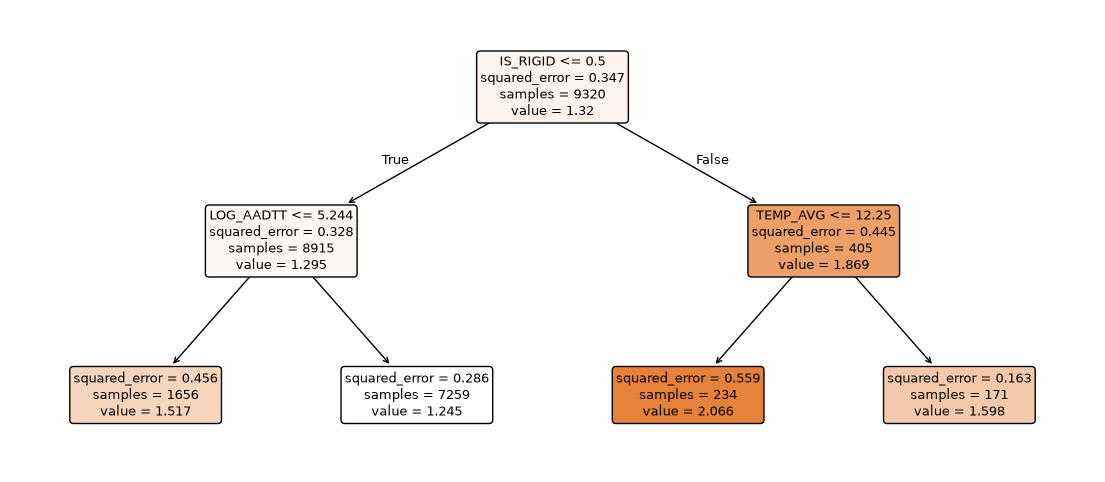

In [69]:
from sklearn.tree import plot_tree

small_tree = DecisionTreeRegressor(max_depth=2).fit(X_A[tr], y_lag[tr])
plt.figure(figsize=(14, 6))
plot_tree(small_tree, feature_names=features, filled=True, rounded=True, fontsize=9)
plt.show()

In [70]:
from sklearn.ensemble import RandomForestRegressor

forest_A = RandomForestRegressor(n_estimators=300, min_samples_leaf=5,
                                 n_jobs=-1, random_state=42)
forest_A.fit(X_A[tr], y_lag[tr])
report("Forest A train", y_lag[tr], forest_A.predict(X_A[tr]))
report("Forest A test", y_lag[te], forest_A.predict(X_A[te]))

Forest A train  R² =  0.712   RMSE = 0.316   MAE = 0.210
Forest A test  R² =  0.351   RMSE = 0.492   MAE = 0.332


### Checking for site leakage
Forest A scored test R² 0.351, suspiciously high. SPS sections at the same site share traffic and climate, so sister sections may be on both sides of the split.

In [71]:
df_lag["SITE_ID"] = np.where(
    df_lag["GPS_SPS"] == "S",
    df_lag["STATE_CODE"].astype(str).str.zfill(2) + "_" + df_lag["SHRP_ID"].str[:2],
    df_lag["SECTION_ID"]
)

print("Sections:", df_lag["SECTION_ID"].nunique())
print("Sites:   ", df_lag["SITE_ID"].nunique())

Sections: 1527
Sites:    792


In [72]:
from sklearn.model_selection import GroupKFold, cross_val_score

X_B = df_lag[features_lag].to_numpy()
sites = df_lag["SITE_ID"].to_numpy()
sections = df_lag["SECTION_ID"].to_numpy()
cv = GroupKFold(n_splits=5)

for split_name, grp in [("by SECTION", sections), ("by SITE", sites)]:
    print(f"\nSplit {split_name}")
    for model_name, model, X_use in [
        ("Linear A", LinearRegression(), X_A),
        ("Forest A", RandomForestRegressor(n_estimators=200, min_samples_leaf=5, n_jobs=-1, random_state=42), X_A),
        ("Linear B", LinearRegression(), X_B),
        ("Forest B", RandomForestRegressor(n_estimators=200, min_samples_leaf=5, n_jobs=-1, random_state=42), X_B),
    ]:
        scores = cross_val_score(model, X_use, y_lag, groups=grp, cv=cv, scoring="r2")
        print(f"  {model_name}:  mean R² = {scores.mean():.3f}")


Split by SECTION
  Linear A:  mean R² = 0.082
  Forest A:  mean R² = 0.345
  Linear B:  mean R² = 0.927
  Forest B:  mean R² = 0.927

Split by SITE
  Linear A:  mean R² = 0.027
  Forest A:  mean R² = 0.092
  Linear B:  mean R² = 0.924
  Forest B:  mean R² = 0.920


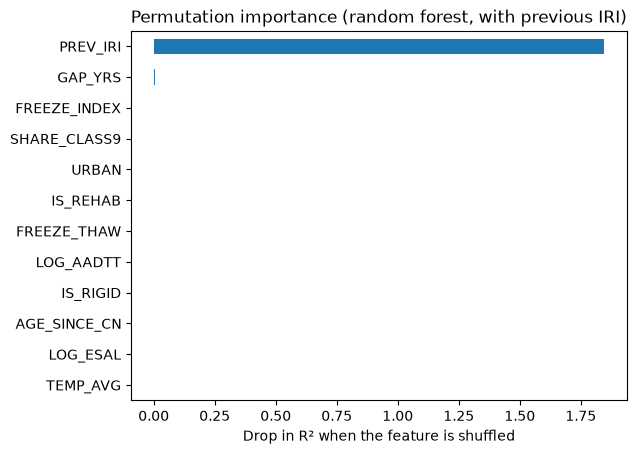

In [73]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.inspection import permutation_importance

site_split = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_s, te_s = next(site_split.split(X_B, y_lag, groups=sites))

forest_B = RandomForestRegressor(n_estimators=300, min_samples_leaf=5, n_jobs=-1, random_state=42)
forest_B.fit(X_B[tr_s], y_lag[tr_s])

perm = permutation_importance(forest_B, X_B[te_s], y_lag[te_s], n_repeats=5, random_state=42)
importance = pd.Series(perm.importances_mean, index=features_lag).sort_values()

importance.plot(kind="barh")
plt.xlabel("Drop in R² when the feature is shuffled")
plt.title("Permutation importance (random forest, with previous IRI)")
plt.show()

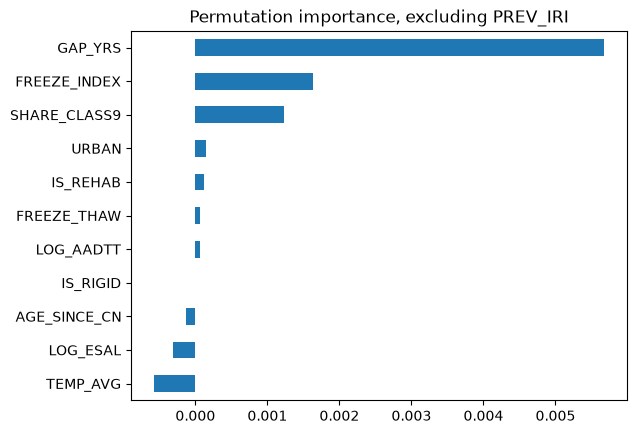

In [74]:
importance.drop("PREV_IRI").plot(kind="barh")
plt.title("Permutation importance, excluding PREV_IRI")
plt.show()

**Result:** splitting by site drops Forest A from 0.345 to 0.092, so most of its skill was recognising sites. With previous IRI, forest and linear models perform the same (about 0.92). PREV_IRI dominates importance; GAP_YRS is next.

## Step 11: Classification, predicting poor condition (IRI > 2.68 m/km)

In [75]:
y_poor = (df_lag["IRI_AVG"] > 2.68).astype(int).to_numpy()

print("Share of poor measurements:", y_poor.mean().round(3))
print("Poor roads in the test set:", y_poor[te_s].sum(), "of", len(te_s))

Share of poor measurements: 0.04
Poor roads in the test set: 97 of 2295


In [76]:
mu_B = X_B[tr_s].mean(axis=0)
sigma_B = X_B[tr_s].std(axis=0)
Xtr_c = zscore_normalize(X_B[tr_s], mu_B, sigma_B)
Xte_c = zscore_normalize(X_B[te_s], mu_B, sigma_B)
ytr_c, yte_c = y_poor[tr_s], y_poor[te_s]

In [77]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost_logistic(X, y, w, b):
    m = X.shape[0]
    f = sigmoid(X @ w + b)
    f = np.clip(f, 1e-15, 1 - 1e-15)
    cost = -np.sum(y * np.log(f) + (1 - y) * np.log(1 - f)) / m
    return cost

def compute_gradient_logistic(X, y, w, b):
    m = X.shape[0]
    errors = sigmoid(X @ w + b) - y
    dj_dw = (X.T @ errors) / m
    dj_db = np.sum(errors) / m
    return dj_dw, dj_db

In [78]:
w = np.zeros(Xtr_c.shape[1])
b = 0.0
alpha = 0.5

print("Starting cost:", round(compute_cost_logistic(Xtr_c, ytr_c, w, b), 4))

for i in range(5000):
    dj_dw, dj_db = compute_gradient_logistic(Xtr_c, ytr_c, w, b)
    w = w - alpha * dj_dw
    b = b - alpha * dj_db
    if i % 1000 == 0:
        print(f"Iteration {i}: cost = {compute_cost_logistic(Xtr_c, ytr_c, w, b):.4f}")

w_log, b_log = w, b

Starting cost: 0.6931
Iteration 0: cost = 0.5865
Iteration 1000: cost = 0.0407
Iteration 2000: cost = 0.0391
Iteration 3000: cost = 0.0387
Iteration 4000: cost = 0.0385


In [79]:
prob_poor = sigmoid(Xte_c @ w_log + b_log)
pred_poor = (prob_poor >= 0.5).astype(int)
print("Predicted poor:", pred_poor.sum(), "  Actually poor:", yte_c.sum())

Predicted poor: 72   Actually poor: 97


In [80]:
from sklearn.linear_model import LogisticRegression

clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
clf.fit(X_B[tr_s], y_poor[tr_s])

prob_sk = clf.predict_proba(X_B[te_s])[:, 1]
pred_sk = clf.predict(X_B[te_s])

print("Your w:   ", w_log.round(2))
print("sklearn w:", clf[-1].coef_[0].round(2))

Your w:    [-0.16 -0.05 -0.14 -0.22 -0.4   0.51 -0.09 -0.04  0.14  0.16  3.28  0.59]
sklearn w: [-0.16 -0.06 -0.13 -0.22 -0.4   0.51 -0.09 -0.04  0.15  0.17  3.33  0.61]


### Evaluating the classifier
Precision = share of flagged roads that are really poor. Recall = share of poor roads that were caught.

In [81]:
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score)

def class_report(name, y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    print(f"{name:22s} acc={accuracy_score(y_true, y_pred):.3f}  "
          f"prec={precision_score(y_true, y_pred, zero_division=0):.3f}  "
          f"rec={recall_score(y_true, y_pred):.3f}  "
          f"f1={f1_score(y_true, y_pred):.3f}   TP={tp} FN={fn} FP={fp}")

In [82]:
yt = y_poor[te_s]
always_good = np.zeros(len(yt), dtype=int)
persistence = (df_lag["PREV_IRI"].to_numpy()[te_s] > 2.68).astype(int)

class_report("Always 'not poor'", yt, always_good)
class_report("Persistence", yt, persistence)
class_report("Logistic (0.5)", yt, pred_sk)

Always 'not poor'      acc=0.958  prec=0.000  rec=0.000  f1=0.000   TP=0 FN=97 FP=0
Persistence            acc=0.981  prec=0.922  rec=0.608  f1=0.733   TP=59 FN=38 FP=5
Logistic (0.5)         acc=0.981  prec=0.875  rec=0.649  f1=0.746   TP=63 FN=34 FP=9


In [83]:
for threshold in [0.5, 0.3, 0.1]:
    pred_t = (prob_sk >= threshold).astype(int)
    class_report(f"Threshold {threshold}", yt, pred_t)

Threshold 0.5          acc=0.981  prec=0.875  rec=0.649  f1=0.746   TP=63 FN=34 FP=9
Threshold 0.3          acc=0.981  prec=0.765  rec=0.804  f1=0.784   TP=78 FN=19 FP=24
Threshold 0.1          acc=0.959  prec=0.512  rec=0.876  f1=0.646   TP=85 FN=12 FP=81


In [84]:
clf_bal = make_pipeline(StandardScaler(),
                        LogisticRegression(class_weight="balanced", max_iter=1000))
clf_bal.fit(X_B[tr_s], y_poor[tr_s])
class_report("Balanced weights", yt, clf_bal.predict(X_B[te_s]))

Balanced weights       acc=0.932  prec=0.377  rec=0.918  f1=0.535   TP=89 FN=8 FP=147


In [85]:
X_A_all = df_lag[features].to_numpy()
clf_A = make_pipeline(StandardScaler(),
                      LogisticRegression(class_weight="balanced", max_iter=1000))
clf_A.fit(X_A_all[tr_s], y_poor[tr_s])
class_report("No previous IRI", yt, clf_A.predict(X_A_all[te_s]))

No previous IRI        acc=0.696  prec=0.065  rec=0.464  f1=0.114   TP=45 FN=52 FP=645


In [86]:
pd.Series(clf[-1].coef_[0], index=features_lag).sort_values(key=abs, ascending=False)

PREV_IRI        3.330429
GAP_YRS         0.605659
LOG_AADTT       0.509053
LOG_ESAL       -0.402961
URBAN          -0.220142
FREEZE_THAW     0.167545
AGE_SINCE_CN   -0.164633
FREEZE_INDEX    0.146130
IS_RIGID       -0.133266
SHARE_CLASS9   -0.093601
IS_REHAB       -0.055801
TEMP_AVG       -0.039695
dtype: float64

**Result:** always "not poor" is 95.8% accurate but catches no poor roads. Logistic regression (threshold 0.5) catches 65% of poor roads at 88% precision, vs 61% and 92% for persistence. Lowering the threshold to 0.3 catches 80%. Without previous IRI, only 6.5% of flags are correct.

## Conclusions
1. Traffic, climate and section attributes alone explain little roughness (R² below 0.1).
2. Previous IRI dominates; the other features add about 9% improvement over persistence.
3. How the data is split (by section or by site) changes the conclusions for flexible models.
4. Always compare with simple baselines.